In [79]:
#%%
from environments.utils.predict_utils import Predictor, EarlyStopping, ETDataset, Forecaster, load_model
from environments.Data.EMS.EMS_constants import *
import numpy as np
from environments.utils.funcionesEMS import *
import torch
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import pandas as pd


In [26]:
# split data in training and validation sets
et_data = pd.read_csv('environments/Data/WMS/extracted_data.csv')["ET_0"].values

mean, std = np.mean(et_data), np.std(et_data)

train_data = ETDataset(torch.tensor((et_data[:int(len(et_data) * 0.8)] - mean)/std, dtype=torch.float32))
val_data = ETDataset(torch.tensor((et_data[int(len(et_data) * 0.8):] - mean)/std, dtype=torch.float32))

dataloader = DataLoader(train_data, batch_size=512, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=128, shuffle=False)

In [65]:
# create a training loop
mdl = Predictor(1, 64, 2, mean, std, pred_steps=7)

optimizer = torch.optim.RAdam(mdl.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()#torch.nn.HuberLoss(delta=0.1)
num_epochs = 50

# Training loop
training_losses = []
validation_losses = []
for epoch in range(num_epochs):
    mdl.train()

    epoch_loss = 0.0
    validation_loss = 0.0
    n = 0 # Counter for the number of batches processed
    for x_batch, y_batch in dataloader:

        optimizer.zero_grad()
        outputs = mdl.forward(x_batch, n_steps=7)
        #print(outputs.shape, y_batch.shape)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    #training_losses.append(epoch_loss.item())

    # Validation step
    mdl.eval()
    m = 0
    with torch.no_grad():
        for x_val_batch, y_val_batch in val_dataloader:
            val_outputs = mdl.forward(x_val_batch, n_steps=7)
            val_loss = criterion(val_outputs, y_val_batch)

            validation_loss += val_loss.item()
            m += 1
    validation_loss /= m  # Average loss over the validation batches
    validation_losses.append(validation_loss)

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss}")
    print(f"Epoch {epoch + 1}/{num_epochs}, Val Loss: {validation_loss}")

# Save the model
mdl.save("et_model.pt")

Epoch 1/50, Loss: 0.0
Epoch 1/50, Val Loss: 0.7855326624020286
Epoch 2/50, Loss: 0.0
Epoch 2/50, Val Loss: 0.3062911590804224
Epoch 3/50, Loss: 0.0
Epoch 3/50, Val Loss: 0.20148056292015573
Epoch 4/50, Loss: 0.0
Epoch 4/50, Val Loss: 0.16055769667677258
Epoch 5/50, Loss: 0.0
Epoch 5/50, Val Loss: 0.1418746625599654
Epoch 6/50, Loss: 0.0
Epoch 6/50, Val Loss: 0.12846275095058524
Epoch 7/50, Loss: 0.0
Epoch 7/50, Val Loss: 0.11903950134697168
Epoch 8/50, Loss: 0.0
Epoch 8/50, Val Loss: 0.11141987517476082
Epoch 9/50, Loss: 0.0
Epoch 9/50, Val Loss: 0.10021490538897722
Epoch 10/50, Loss: 0.0
Epoch 10/50, Val Loss: 0.09456959739327431
Epoch 11/50, Loss: 0.0
Epoch 11/50, Val Loss: 0.08736746580056522
Epoch 12/50, Loss: 0.0
Epoch 12/50, Val Loss: 0.08324923107157582
Epoch 13/50, Loss: 0.0
Epoch 13/50, Val Loss: 0.08855057248602742
Epoch 14/50, Loss: 0.0
Epoch 14/50, Val Loss: 0.08082674281752628
Epoch 15/50, Loss: 0.0
Epoch 15/50, Val Loss: 0.08167870261746904
Epoch 16/50, Loss: 0.0
Epoch 16

KeyboardInterrupt: 

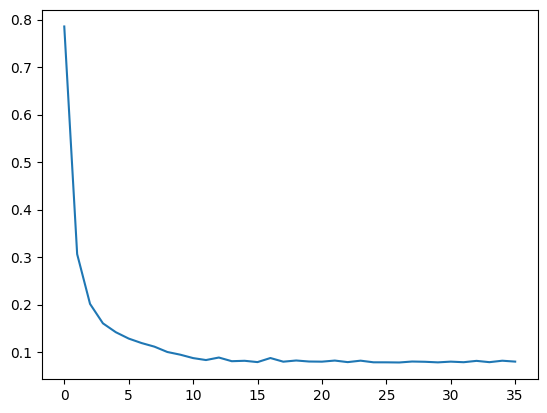

In [83]:
mdl.save("predictive_models/et_model.pt")
plt.plot(validation_losses, label='Validation Loss')

In [61]:
validation_losses

[0.07893415864395059]

Text(0.5, 1.0, 'Predicted vs True Values')

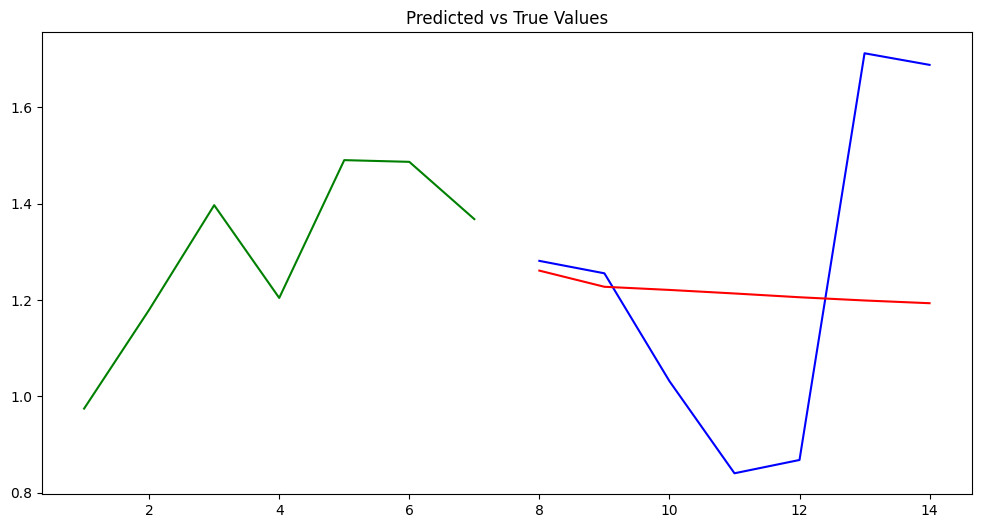

In [77]:
for x, y in dataloader:
    break
with torch.no_grad():
    y_pred = mdl.forward(x, n_steps=7)
# Plot the predictions
plt.figure(figsize=(12, 6))
plt.plot([1,2,3,4,5,6,7], x[0].numpy().flatten(), label='Input Data', color='green')
plt.plot([8,9,10,11,12,13,14], y[0].numpy().flatten()[-7:], label='True Values', color='blue')
plt.plot([8,9,10,11,12,13,14], y_pred[0].numpy().flatten()[-7:], label='Predicted Values', color='red')
plt.title('Predicted vs True Values')

In [ ]:
For

In [41]:
x.shape

torch.Size([512, 7, 1])

In [53]:
print(mdl(x).shape, y.shape)
criterion(mdl(x), y).shape

torch.Size([512, 7, 1]) torch.Size([512, 13, 1])


C:\Users\CASI 5\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\loss.py:1102: UserWarning: Using a target size (torch.Size([512, 13, 1])) that is different to the input size (torch.Size([512, 7, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)


RuntimeError: The size of tensor a (7) must match the size of tensor b (13) at non-singleton dimension 1

In [80]:
model = load_model("et_model.pt")
forecaster = Forecaster(model)

c:\Users\CASI 5\Documents\RL_EMS\environments\utils\predict_utils.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(mean, dtype=torch.float32).to(device)
c:\Users\CASI 5\Documents\RL_EMS\environments\utils\predict_utils.py:132: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(std, dtype=torch.float32).to(device)


In [82]:
forecaster.predict(et_data[0:7], n_steps=7)

array([5.0152817, 4.957973 , 4.9512362, 4.9345007, 4.9175916, 4.9037013,
       4.8918486], dtype=float32)